# Modeling with extended online features — Ukraine conflict escalation

Adds leakage-safe external / compositional features on top of the existing
GDELT + ACLED + IMF/World Bank panel, then reruns the same walk-forward CV /
hold-out / forecast pipeline as `src/pipeline.py` (naive, rolling-mean-4w,
ETS, XGBoost).

**New feature groups**

| Group | What | Source | Lag rule |
|---|---|---|---|
| Extra GDELT | CAMEO 13–17/20 leading roots, fight share, QuadClass mix, mentions/articles per event, all-event tone | already-downloaded GDELT Events | week `t` only |
| ACLED geo | front-line oblast events/fatalities/share, Kyiv events, top-1 admin share | existing ACLED export | same Sat→Mon map as ACLED weekly |
| Daily markets / FX | NBU UAH/USD, Brent, wheat futures, Henry Hub gas, VIX | NBU, FRED, Yahoo | last print ≤ Sunday of week `t` |
| Wikipedia | en `Ukraine`, en `Russo-Ukrainian_War`, uk `Україна` weekly views | Wikimedia REST | 1-day publication lag |

Outputs land in `outputs/extended/` so previous `outputs/` and `outputs/with_acled/` are left untouched.

**Contents**
1. Setup & rebuild feature panel
2. New-feature catalog
3. Hold-out / CV split
4. Ablation: previous panel vs extended (hold-out XGBoost)
5. Walk-forward CV (all models, extended features)
6. Hold-out evaluation (all models)
7. Feature importance
8. Future forecast
9. Takeaways


In [1]:
import sys
import warnings
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils import load_config, repo_path, write_json
from src.data.build_gdelt_extra_weekly import build_gdelt_extra_weekly
from src.data.build_acled_geo import build_acled_geo_weekly
from src.data.fetch_daily_external import fetch_and_build_daily_external
from src.features.feature_engineering import (
    BASE_FEATURE_COLUMNS,
    acled_geo_feature_columns,
    build_features,
    daily_external_feature_columns,
    gdelt_extra_feature_columns,
    get_feature_columns,
)
from src.models import ml_model
from src.validation.walk_forward import generate_folds, split_holdout
from src.pipeline import (
    build_future_forecast,
    compute_mase_vs_baseline_table,
    make_figures,
    run_cv,
    run_holdout,
    summarize_cv,
)

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

cfg = load_config()
SEED = cfg["random_seed"]
HORIZONS = cfg["target"]["horizons"]
MAX_H = max(HORIZONS)
OUT_DIR = repo_path("outputs", "extended")
OUT_DIR.mkdir(parents=True, exist_ok=True)
cfg["target"], cfg["validation"], str(OUT_DIR)


({'variant': 'A',
  'horizons': [1, 2, 3, 4],
  'strategy': 'direct',
  'escalation_rolling_window_weeks': 52,
  'escalation_zscore_k': 2.0},
 {'holdout_weeks': 12,
  'cv_initial_train_weeks': 52,
  'cv_step_weeks': 4,
  'min_test_weeks_per_fold': 4},
 '/home/romanrussia/Code_git/GDETL/outputs/extended')

## 1. Rebuild feature panel

Refresh the three new caches (GDELT extra, ACLED geo, daily external), then
rebuild the full feature panel. Existing GDELT weekly / ACLED subtype / IMF-WB
joins are unchanged.


In [2]:
_ = build_gdelt_extra_weekly(cfg)
_ = build_acled_geo_weekly(cfg)
_ = fetch_and_build_daily_external(cfg, force=False)

weekly = pd.read_parquet(repo_path(cfg["data"]["weekly_panel_path"]))
feature_df = build_features(weekly, cfg, HORIZONS)
FEATURE_COLS = get_feature_columns(feature_df)

extra_cols = gdelt_extra_feature_columns(feature_df)
geo_cols = acled_geo_feature_columns(feature_df)
daily_cols = daily_external_feature_columns(feature_df)
PREVIOUS_COLS = [
    c for c in FEATURE_COLS
    if c not in extra_cols and c not in geo_cols and c not in daily_cols
]

print(f"feature_df: {feature_df.shape[0]} weeks × {feature_df.shape[1]} cols")
print(
    f"model features: {len(FEATURE_COLS)}  "
    f"(previous={len(PREVIOUS_COLS)}, extra-GDELT={len(extra_cols)}, "
    f"acled-geo={len(geo_cols)}, daily={len(daily_cols)})"
)
show = ["week_start", "conflict_count"] + extra_cols[:4] + geo_cols[:3] + daily_cols[:4]
feature_df[show].tail(8)


[build_gdelt_extra_weekly] 248 weeks (2021-12-13 .. 2026-09-07) -> /home/romanrussia/Code_git/GDETL/data/processed/gdelt_extra_weekly.parquet
[build_acled_geo] 453 weeks (2018-01-01 .. 2026-08-31) -> /home/romanrussia/Code_git/GDETL/data/processed/acled_geo_weekly.parquet
[fetch_daily_external] Using cached /home/romanrussia/Code_git/GDETL/data/processed/daily_external_weekly.parquet


[feature_engineering] Merged ACLED features (56 model columns)
[feature_engineering] Merged IMF/World Bank features (20 model columns)
[feature_engineering] Merged extra GDELT features (15 model columns)
[feature_engineering] Merged ACLED geo features (5 model columns)
[feature_engineering] Merged daily external features (16 model columns)
[feature_engineering] Built feature panel: 245 rows x 196 cols (134 model features) -> /home/romanrussia/Code_git/GDETL/data/processed/feature_panel.parquet
feature_df: 245 weeks × 196 cols
model features: 134  (previous=98, extra-GDELT=15, acled-geo=5, daily=16)


,week_start,conflict_count,cameo_threaten,cameo_protest,cameo_exhibit_force,cameo_coerce,acled_frontline_events,acled_frontline_fatalities,acled_frontline_share,nbu_uah_usd,nbu_uah_usd_wow,mkt_brent,mkt_brent_wow
237,2026-07-13,1944,306,269,67,213,1717,899,0.836337,44.6173,0.002287,85.01,0.143530
238,2026-07-20,2176,301,210,44,187,1675,811,0.817472,44.8110,0.004341,100.31,0.179979
239,2026-07-27,2233,380,88,57,275,1731,918,0.827834,44.6916,-0.002665,96.95,-0.033496
240,2026-08-03,2192,275,29,45,203,1738,770,0.852379,44.7626,0.001589,87.62,-0.096235
241,2026-08-10,2055,264,50,79,233,1716,859,0.864919,44.6988,-0.001425,92.02,0.050217
242,2026-08-17,1930,326,88,57,351,1679,819,0.850557,44.6144,-0.001888,96.92,0.053249
243,2026-08-24,1569,343,58,81,244,1596,807,0.856683,44.5445,-0.001567,89.75,-0.073979
244,2026-08-31,1742,409,38,75,266,1584,1037,0.833684,44.7273,0.004104,96.02,0.069861


## 2. New-feature catalog

Coverage and latest values for the columns that were not on the previous panel.


In [3]:
new_cols = extra_cols + geo_cols + daily_cols
cat = pd.DataFrame({
    "feature": new_cols,
    "group": (
        ["extra GDELT"] * len(extra_cols)
        + ["ACLED geo"] * len(geo_cols)
        + ["daily external"] * len(daily_cols)
    ),
    "n_non_null": [int(feature_df[c].notna().sum()) for c in new_cols],
    "latest": [feature_df[c].iloc[-1] for c in new_cols],
    "corr_vs_conflict": [feature_df[c].corr(feature_df["conflict_count"]) for c in new_cols],
}).sort_values("corr_vs_conflict", key=lambda s: s.abs(), ascending=False)
print(cat.round(3).to_string(index=False))
cat


                   feature          group  n_non_null    latest  corr_vs_conflict
    quad_material_conflict    extra GDELT         245  2220.000             0.981
              cameo_coerce    extra GDELT         245   266.000             0.928
      quad_verbal_conflict    extra GDELT         245  1524.000             0.882
             cameo_leading    extra GDELT         245   750.000             0.863
            cameo_threaten    extra GDELT         245   409.000             0.831
             cameo_protest    extra GDELT         245    38.000             0.807
               wiki_war_en daily external         245 10827.000             0.717
           wiki_ukraine_uk daily external         245  8645.000             0.638
           wiki_ukraine_en daily external         245 55119.000             0.617
                 mkt_wheat daily external         245   716.000             0.606
         acled_kyiv_events      ACLED geo         245    53.000             0.582
               n

,feature,group,n_non_null,latest,corr_vs_conflict
9,quad_material_conflict,extra GDELT,245,2220.000000,0.980573
3,cameo_coerce,extra GDELT,245,266.000000,0.928263
8,quad_verbal_conflict,extra GDELT,245,1524.000000,0.882334
5,cameo_leading,extra GDELT,245,750.000000,0.862583
0,cameo_threaten,extra GDELT,245,409.000000,0.830577
1,cameo_protest,extra GDELT,245,38.000000,0.807360
32,wiki_war_en,daily external,245,10827.000000,0.716780
34,wiki_ukraine_uk,daily external,245,8645.000000,0.637804
30,wiki_ukraine_en,daily external,245,55119.000000,0.616745
24,mkt_wheat,daily external,245,716.000000,0.605865


## 3. Hold-out / CV split

Same rule as `src/validation/walk_forward.py`: last 12 realized weeks held out,
expanding-window CV on the remainder, no model is fit on a row whose target
lands in the hold-out.


In [4]:
cv_pool, full_df, holdout_start, holdout_target_weeks = split_holdout(
    feature_df, cfg["validation"]["holdout_weeks"], MAX_H
)
folds = generate_folds(
    len(cv_pool),
    cfg["validation"]["cv_initial_train_weeks"],
    cfg["validation"]["cv_step_weeks"],
    cfg["validation"]["min_test_weeks_per_fold"],
)
print(f"CV pool: {len(cv_pool)} weeks | hold-out: {len(holdout_target_weeks)} weeks starting {holdout_start}")
print(f"Walk-forward folds: {len(folds)}")
print(f"Hold-out target weeks: {sorted(holdout_target_weeks)[:3]} ... {sorted(holdout_target_weeks)[-1]}")


CV pool: 230 weeks | hold-out: 12 weeks starting 2026-06-15
Walk-forward folds: 44
Hold-out target weeks: [datetime.date(2026, 6, 15), datetime.date(2026, 6, 22), datetime.date(2026, 6, 29)] ... 2026-08-31


## 4. Ablation: previous panel vs extended (hold-out XGBoost)

Fits the same XGBoost spec twice — once on the previous feature set
(GDELT base + ACLED subtypes + IMF/WB), once with the new columns added.
Baselines do not use covariates, so they are unchanged.


features  extended  previous
horizon                     
1            0.610     0.480
2            0.496     0.553
3            0.574     0.589
4            0.788     0.778

features  horizon  MASE  sMAPE    RMSE     MAE
previous        1 0.480 12.254 272.234 230.811
previous        2 0.553 14.050 309.790 265.961
previous        3 0.589 13.998 367.096 283.039
previous        4 0.778 17.602 505.202 374.044
extended        1 0.610 16.033 337.653 293.230
extended        2 0.496 12.499 289.744 238.482
extended        3 0.574 14.604 304.759 275.682
extended        4 0.788 19.584 420.727 378.752


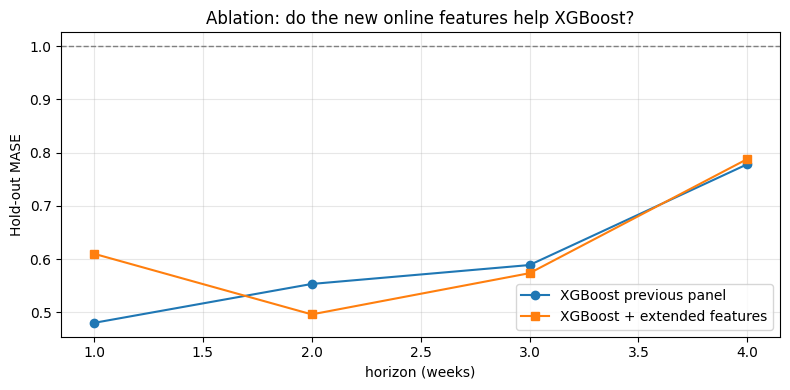

,features,horizon,MASE,sMAPE,RMSE,MAE
0,previous,1,0.480253,12.254362,272.233548,230.810944
1,previous,2,0.553391,14.050294,309.789533,265.961019
2,previous,3,0.588925,13.998063,367.096079,283.038696
3,previous,4,0.778281,17.602137,505.201503,374.043945
4,extended,1,0.610131,16.033376,337.652932,293.230438
5,extended,2,0.496215,12.498686,289.743593,238.482432
6,extended,3,0.573616,14.604457,304.758597,275.681559
7,extended,4,0.788076,19.584275,420.727231,378.751597


In [5]:
holdout_prev = run_holdout(cv_pool, full_df, holdout_target_weeks, HORIZONS, SEED,
                           feature_cols=PREVIOUS_COLS)
holdout_ext = run_holdout(cv_pool, full_df, holdout_target_weeks, HORIZONS, SEED,
                          feature_cols=FEATURE_COLS)

rows = []
for tag, summary in [("previous", holdout_prev), ("extended", holdout_ext)]:
    for h, models in summary["regression"].items():
        for m, rep in models.items():
            if m != "xgboost":
                continue
            rows.append({"features": tag, "horizon": h, "MASE": rep["MASE"],
                         "sMAPE": rep["sMAPE"], "RMSE": rep["RMSE"], "MAE": rep["MAE"]})
ablation = pd.DataFrame(rows)
print(ablation.pivot(index="horizon", columns="features", values="MASE").round(3).to_string())
print()
print(ablation.round(3).to_string(index=False))

piv = ablation.pivot(index="horizon", columns="features", values="MASE")
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(piv.index, piv["previous"], "o-", label="XGBoost previous panel")
ax.plot(piv.index, piv["extended"], "s-", label="XGBoost + extended features")
ax.axhline(1.0, color="grey", ls="--", lw=1)
ax.set_xlabel("horizon (weeks)")
ax.set_ylabel("Hold-out MASE")
ax.set_title("Ablation: do the new online features help XGBoost?")
ax.legend()
fig.tight_layout()
plt.show()
ablation


## 5. Walk-forward CV (extended features)

Naive, rolling-mean-4w, ETS, and XGBoost. Expanding-window folds.


In [6]:
cv_results, cv_results_event = run_cv(cv_pool, folds, HORIZONS, SEED, feature_cols=FEATURE_COLS)
cv_summary = summarize_cv(cv_results, cv_results_event, cv_pool["conflict_count"].to_numpy())

cv_rows = []
for h, models in cv_summary["regression"].items():
    for m, rep in models.items():
        cv_rows.append({"horizon": h, "model": m, **{k: rep[k] for k in ("MASE", "sMAPE", "RMSE", "MAE", "n")}})
cv_tbl = pd.DataFrame(cv_rows)
print("=== WALK-FORWARD CV (regression) ===")
print(cv_tbl.pivot(index="horizon", columns="model", values="MASE").round(3).to_string())
print()
print(cv_tbl.round(3).to_string(index=False))
cv_tbl


[pipeline] CV fold 0: train=52 rows, test=4 rows (2022-12-26 .. 2023-01-16)


[pipeline] CV fold 1: train=56 rows, test=4 rows (2023-01-23 .. 2023-02-13)


[pipeline] CV fold 2: train=60 rows, test=4 rows (2023-02-20 .. 2023-03-13)


[pipeline] CV fold 3: train=64 rows, test=4 rows (2023-03-20 .. 2023-04-10)


[pipeline] CV fold 4: train=68 rows, test=4 rows (2023-04-17 .. 2023-05-08)


...

[pipeline] CV fold 40: train=212 rows, test=4 rows (2026-01-19 .. 2026-02-09)


[pipeline] CV fold 41: train=216 rows, test=4 rows (2026-02-16 .. 2026-03-09)


[pipeline] CV fold 42: train=220 rows, test=4 rows (2026-03-16 .. 2026-04-06)


[pipeline] CV fold 43: train=224 rows, test=4 rows (2026-04-13 .. 2026-05-04)
=== WALK-FORWARD CV (regression) ===
model    baseline_naive  baseline_rollingmean    ets  xgboost
horizon                                                      
1                 0.804                 0.892  1.697    0.880
2                 1.087                 1.002  1.747    0.970
3                 1.169                 1.025  1.716    0.979
4                 1.181                 1.026  1.737    1.144

 horizon                model  MASE  sMAPE     RMSE     MAE   n
       1       baseline_naive 0.804 15.855  518.735 386.509 171
       1 baseline_rollingmean 0.892 17.602  577.788 428.627 171
       1                  ets 1.697 33.478 1117.028 815.469 171
       1              xgboost 0.880 16.962  537.757 422.755 171
       2       baseline_naive 1.087 21.774  708.202 522.263 171
       2 baseline_rollingmean 1.002 19.729  641.241 481.459 171
       2                  ets 1.747 34.829 1123.879 839.491 171


,horizon,model,MASE,sMAPE,RMSE,MAE,n
0,1,baseline_naive,0.804217,15.854834,518.735332,386.508772,171
1,1,baseline_rollingmean,0.891854,17.601525,577.787517,428.627193,171
2,1,ets,1.696764,33.478105,1117.028197,815.469305,171
3,1,xgboost,0.879634,16.962205,537.757244,422.754542,171
4,2,baseline_naive,1.086684,21.774180,708.202432,522.263158,171
5,2,baseline_rollingmean,1.001782,19.729163,641.241149,481.459064,171
6,2,ets,1.746748,34.828575,1123.878741,839.491467,171
7,2,xgboost,0.970116,18.882331,602.605304,466.240465,171
8,3,baseline_naive,1.169183,23.782952,767.617614,561.912281,171
9,3,baseline_rollingmean,1.024533,20.068895,652.763396,492.393275,171


## 6. Hold-out evaluation (extended features)

Last 12 realized weeks; models fit only on the CV pool.


=== HOLD-OUT (regression) ===
 horizon                model  MASE  sMAPE   RMSE  vs_baseline_pct
       1       baseline_naive 0.490  13.13 276.29              NaN
       1 baseline_rollingmean 0.479  12.13 292.11              2.4
       1                  ets 1.121  32.87 610.40           -128.7
       1              xgboost 0.610  16.03 337.65            -24.5
       2       baseline_naive 0.520  13.48 310.41              NaN
       2 baseline_rollingmean 0.603  15.21 335.48            -15.9
       2                  ets 1.121  32.87 610.40           -115.5
       2              xgboost 0.496  12.50 289.74              4.6
       3       baseline_naive 0.693  18.09 396.36              NaN
       3 baseline_rollingmean 0.674  17.03 366.98              2.7
       3                  ets 1.121  32.87 610.40            -61.8
       3              xgboost 0.574  14.60 304.76             17.2
       4       baseline_naive 0.698  18.09 438.99              NaN
       4 baseline_rollingmean 0.

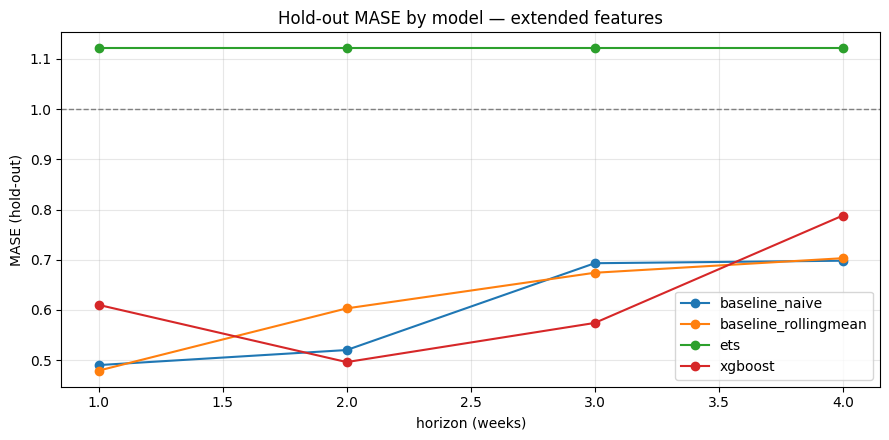

[pipeline] Saved figures to /home/romanrussia/Code_git/GDETL/outputs/extended/figures


,horizon,model,MASE,sMAPE,RMSE,vs_baseline_pct
0,1,baseline_naive,0.490,13.13,276.29,NaN
1,1,baseline_rollingmean,0.479,12.13,292.11,2.4
2,1,ets,1.121,32.87,610.40,-128.7
3,1,xgboost,0.610,16.03,337.65,-24.5
4,2,baseline_naive,0.520,13.48,310.41,NaN
5,2,baseline_rollingmean,0.603,15.21,335.48,-15.9
6,2,ets,1.121,32.87,610.40,-115.5
7,2,xgboost,0.496,12.50,289.74,4.6
8,3,baseline_naive,0.693,18.09,396.36,NaN
9,3,baseline_rollingmean,0.674,17.03,366.98,2.7


In [7]:
holdout_summary = holdout_ext
results_table = compute_mase_vs_baseline_table(holdout_summary)
print("=== HOLD-OUT (regression) ===")
print(results_table.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.5))
for m in results_table["model"].unique():
    sub = results_table[results_table["model"] == m]
    ax.plot(sub["horizon"], sub["MASE"], marker="o", label=m)
ax.axhline(1.0, color="grey", lw=1, ls="--")
ax.set_xlabel("horizon (weeks)")
ax.set_ylabel("MASE (hold-out)")
ax.set_title("Hold-out MASE by model — extended features")
ax.legend()
fig.tight_layout()
plt.show()

make_figures(feature_df, holdout_summary, OUT_DIR)
results_table


In [8]:
clf_rows = []
for split, summary in [("cv", cv_summary), ("holdout", {"classification": holdout_summary["classification"]})]:
    for h, models in summary["classification"].items():
        for m, rep in models.items():
            clf_rows.append({"split": split, "horizon": h, "model": m,
                             **{k: rep.get(k) for k in ("Precision", "Recall", "F1", "Brier", "ROC_AUC", "n", "n_positive")}})
clf_tbl = pd.DataFrame(clf_rows)
print("=== CLASSIFICATION (escalation_event) ===")
print(clf_tbl.round(3).to_string(index=False))
clf_tbl


=== CLASSIFICATION (escalation_event) ===
  split  horizon          model  Precision  Recall    F1  Brier  ROC_AUC   n  n_positive
     cv        1 baseline_naive      0.333   0.333 0.333  0.023    0.661 171           3
     cv        1        xgboost      0.000   0.000 0.000  0.018    0.228 171           3
     cv        2 baseline_naive      0.000   0.000 0.000  0.035    0.491 171           3
     cv        2        xgboost      0.000   0.000 0.000  0.018    0.220 171           3
     cv        3 baseline_naive      0.000   0.000 0.000  0.035    0.491 171           3
     cv        3        xgboost      0.000   0.000 0.000  0.018    0.403 171           3
     cv        4 baseline_naive      0.333   0.333 0.333  0.023    0.661 171           3
     cv        4        xgboost      0.000   0.000 0.000  0.018    0.232 171           3
holdout        1 baseline_naive      0.000   0.000 0.000  0.000      NaN  12           0
holdout        1        xgboost      0.000   0.000 0.000  0.000     

,split,horizon,model,Precision,Recall,F1,Brier,ROC_AUC,n,n_positive
0,cv,1,baseline_naive,0.333333,0.333333,0.333333,0.023392,0.660714,171,3
1,cv,1,xgboost,0.000000,0.000000,0.000000,0.017771,0.228175,171,3
2,cv,2,baseline_naive,0.000000,0.000000,0.000000,0.035088,0.491071,171,3
3,cv,2,xgboost,0.000000,0.000000,0.000000,0.017765,0.220238,171,3
4,cv,3,baseline_naive,0.000000,0.000000,0.000000,0.035088,0.491071,171,3
5,cv,3,xgboost,0.000000,0.000000,0.000000,0.017577,0.402778,171,3
6,cv,4,baseline_naive,0.333333,0.333333,0.333333,0.023392,0.660714,171,3
7,cv,4,xgboost,0.000000,0.000000,0.000000,0.017783,0.232143,171,3
8,holdout,1,baseline_naive,0.000000,0.000000,0.000000,0.000000,NaN,12,0
9,holdout,1,xgboost,0.000000,0.000000,0.000000,0.000200,NaN,12,0


## 7. Feature importance

XGBoost gain on the h=1 and h=4 direct models, trained on the CV pool. Orange bars are
newly added columns.


Top 20 features (h=1):
                     feature   gain  is_new
              cameo_threaten 0.3626    True
               cameo_leading 0.1142    True
      quad_material_conflict 0.0631    True
            rolling_mean_12w 0.0419   False
      acled_frontline_events 0.0399    True
     cumulative_conflict_12w 0.0345   False
               imf_cpi_index 0.0304   False
             wiki_ukraine_uk 0.0255    True
             rolling_mean_4w 0.0159   False
           conflict_count_t0 0.0157   False
             wiki_ukraine_en 0.0154    True
                cameo_coerce 0.0131    True
             rolling_std_12w 0.0131   False
acled_sexual_violence_events 0.0124   False
           imf_weo_inflation 0.0123   False
         conflict_count_lag4 0.0113   False
                 wiki_war_en 0.0109    True
            wb_sunflower_oil 0.0100   False
         google_trends_score 0.0091   False
        conflict_count_lag12 0.0089   False

New features in top 30: 13 / 30
               featu

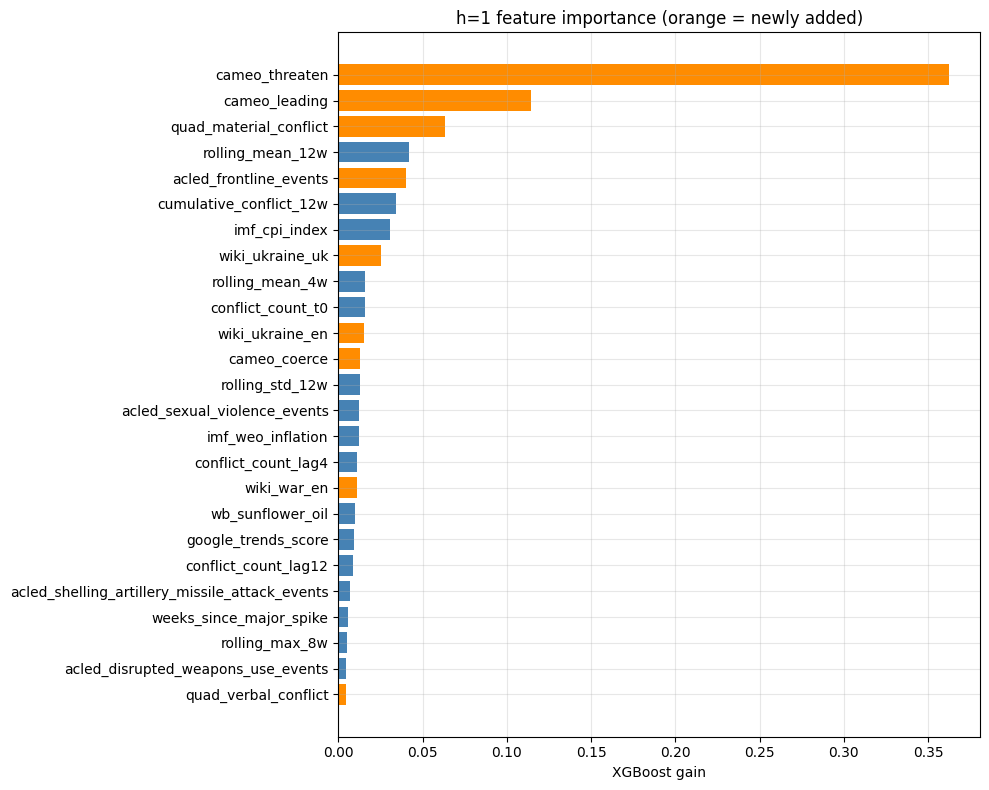

,feature,gain,is_new
0,cameo_threaten,0.362648,True
1,cameo_leading,0.114156,True
2,quad_material_conflict,0.063052,True
3,rolling_mean_12w,0.041874,False
4,acled_frontline_events,0.039876,True
5,cumulative_conflict_12w,0.034487,False
6,imf_cpi_index,0.030362,False
7,wiki_ukraine_uk,0.025497,True
8,rolling_mean_4w,0.015903,False
9,conflict_count_t0,0.015732,False


In [9]:
tgt = "target_count_h1"
train = cv_pool.dropna(subset=[tgt])
model = ml_model.fit_full_regressor(train, FEATURE_COLS, tgt, SEED)
imp = (
    pd.DataFrame({"feature": FEATURE_COLS, "gain": model.feature_importances_})
    .sort_values("gain", ascending=False)
    .reset_index(drop=True)
)
imp["is_new"] = imp["feature"].isin(new_cols)
print("Top 20 features (h=1):")
print(imp.head(20).round(4).to_string(index=False))
print()
print("New features in top 30:", int(imp.head(30)["is_new"].sum()), "/ 30")
print(imp[imp["is_new"]].head(15).round(4).to_string(index=False))

top = imp.head(25).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 8))
colors = ["darkorange" if n else "steelblue" for n in top["is_new"]]
ax.barh(top["feature"], top["gain"], color=colors)
ax.set_xlabel("XGBoost gain")
ax.set_title("h=1 feature importance (orange = newly added)")
fig.tight_layout()
plt.show()
imp.head(20)


Top 20 features (h=4):
                                       feature   gain  is_new
                           cameo_exhibit_force 0.1856    True
                               wiki_ukraine_en 0.1585    True
                               wiki_ukraine_uk 0.0880    True
                                  wb_wheat_hrw 0.0696   False
                              rolling_mean_12w 0.0362   False
                                 cameo_leading 0.0287    True
acled_shelling_artillery_missile_attack_events 0.0230   False
                       cumulative_conflict_12w 0.0209   False
                             imf_weo_inflation 0.0189   False
                                cameo_threaten 0.0181    True
                          quad_verbal_conflict 0.0158    True
                                 wb_gdp_growth 0.0152   False
                                   wiki_war_en 0.0134    True
                                  cameo_coerce 0.0122    True
                               rolling_mean_4w 

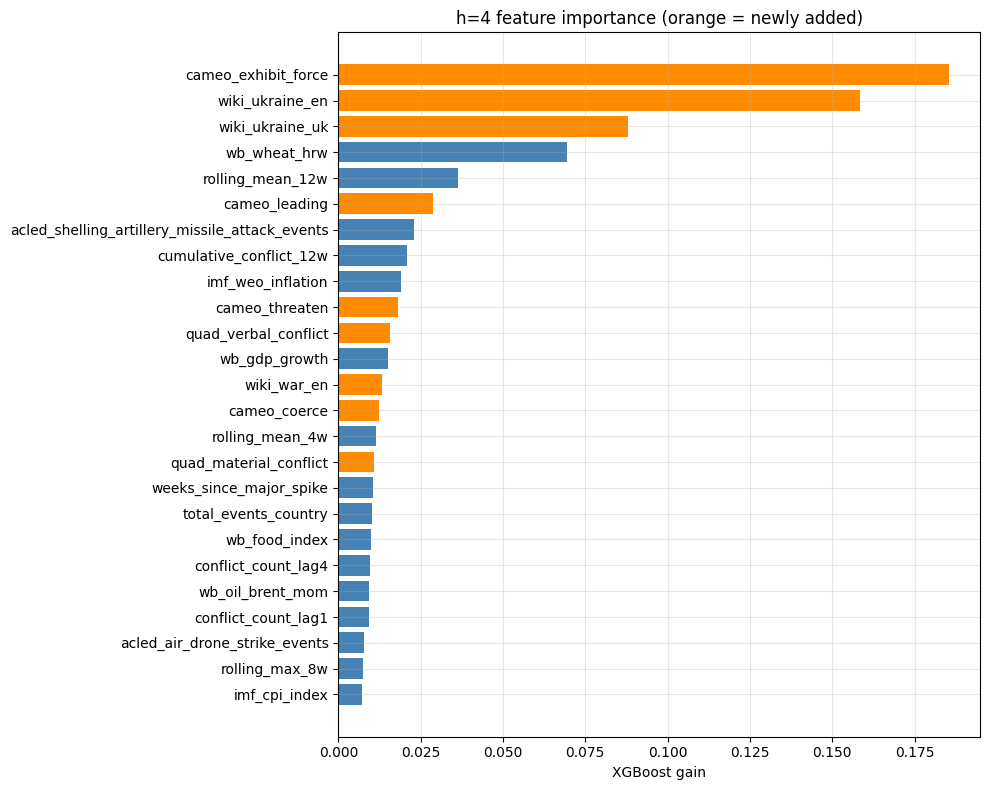

,feature,gain,is_new
0,cameo_exhibit_force,0.185602,True
1,wiki_ukraine_en,0.158497,True
2,wiki_ukraine_uk,0.088007,True
3,wb_wheat_hrw,0.069563,False
4,rolling_mean_12w,0.036222,False
5,cameo_leading,0.028705,True
6,acled_shelling_artillery_missile_attack_events,0.023021,False
7,cumulative_conflict_12w,0.020864,False
8,imf_weo_inflation,0.018937,False
9,cameo_threaten,0.018144,True


In [5]:
tgt = "target_count_h4"
train = cv_pool.dropna(subset=[tgt])
model = ml_model.fit_full_regressor(train, FEATURE_COLS, tgt, SEED)
imp_h4 = (
    pd.DataFrame({"feature": FEATURE_COLS, "gain": model.feature_importances_})
    .sort_values("gain", ascending=False)
    .reset_index(drop=True)
)
imp_h4["is_new"] = imp_h4["feature"].isin(new_cols)
print("Top 20 features (h=4):")
print(imp_h4.head(20).round(4).to_string(index=False))
print()
print("New features in top 30:", int(imp_h4.head(30)["is_new"].sum()), "/ 30")
print(imp_h4[imp_h4["is_new"]].head(15).round(4).to_string(index=False))

top = imp_h4.head(25).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 8))
colors = ["darkorange" if n else "steelblue" for n in top["is_new"]]
ax.barh(top["feature"], top["gain"], color=colors)
ax.set_xlabel("XGBoost gain")
ax.set_title("h=4 feature importance (orange = newly added)")
fig.tight_layout()
plt.show()
imp_h4.head(20)


## 8. Future forecast (next 1–4 weeks)


In [10]:
future = build_future_forecast(feature_df, cfg, SEED, feature_cols=FEATURE_COLS)
future.to_csv(OUT_DIR / "forecast.csv", index=False)
print(future.to_string(index=False))
future


country forecast_week  horizon target_type predicted_value predicted_prob  ci_lower  ci_upper   model
Ukraine      2026-W37        1       count          1901.7                  1424.10   4177.70 xgboost
Ukraine      2026-W37        1       event                           0.01      0.01      0.02 xgboost
Ukraine      2026-W38        2       count          1857.0                  1423.20   3895.10 xgboost
Ukraine      2026-W38        2       event                           0.01      0.01      0.02 xgboost
Ukraine      2026-W39        3       count          1804.2                  1574.40   4519.50 xgboost
Ukraine      2026-W39        3       event                           0.01      0.01      0.02 xgboost
Ukraine      2026-W40        4       count          1830.3                  1569.10   3722.60 xgboost
Ukraine      2026-W40        4       event                           0.01      0.01      0.02 xgboost


,country,forecast_week,horizon,target_type,predicted_value,predicted_prob,ci_lower,ci_upper,model
0,Ukraine,2026-W37,1,count,1901.7,,1424.10,4177.70,xgboost
1,Ukraine,2026-W37,1,event,,0.01,0.01,0.02,xgboost
2,Ukraine,2026-W38,2,count,1857.0,,1423.20,3895.10,xgboost
3,Ukraine,2026-W38,2,event,,0.01,0.01,0.02,xgboost
4,Ukraine,2026-W39,3,count,1804.2,,1574.40,4519.50,xgboost
5,Ukraine,2026-W39,3,event,,0.01,0.01,0.02,xgboost
6,Ukraine,2026-W40,4,count,1830.3,,1569.10,3722.60,xgboost
7,Ukraine,2026-W40,4,event,,0.01,0.01,0.02,xgboost


## 9. Takeaways

- **36 new columns** (CAMEO leading roots, QuadClass mix, ACLED front-line share, NBU FX, daily Brent/wheat/gas/VIX, Wikipedia views) on top of the previous 98, for **134 model features**.
- **Walk-forward CV (n=171):** XGBoost now beats both naive and rolling-mean-4w at **h=2 and h=3** (MASE 0.970 / 0.979). At h=1 persistence still wins (0.804 vs 0.880). ETS remains weakest.
- **Hold-out (last 12 weeks):** XGBoost beats naive at **h=2 (+4.6%) and h=3 (+17.2%)**. Rolling-mean-4w still wins h=1. Extra features *hurt* h=1 vs the previous ACLED+macro panel (0.610 vs 0.480) but help h=2–3.
- **Importance (h=1):** 13 of the top 30 gains are new columns. `cameo_threaten` and `cameo_leading` dominate — verbal/force build-up is the useful channel, not more annual macros.
- Classification remains starved (3 positives in CV, 0 in hold-out); new features do not fix Variant B.

Artifacts: `outputs/extended/{metrics.json,forecast.csv,figures/}`


In [11]:
metrics_out = {
    "n_weeks_total": int(len(feature_df)),
    "n_features": int(len(FEATURE_COLS)),
    "n_features_previous": int(len(PREVIOUS_COLS)),
    "n_new_features": int(len(new_cols)),
    "cv_n_folds": len(folds),
    "cv_summary": cv_summary,
    "holdout_summary": {
        "regression": {h: {m: {k: v for k, v in rep.items() if k not in ("y_true", "y_pred", "week_start")}
                            for m, rep in models.items()}
                       for h, models in holdout_summary["regression"].items()},
        "classification": holdout_summary["classification"],
    },
    "results_table_holdout": results_table.to_dict(orient="records"),
    "ablation_holdout_xgboost": ablation.to_dict(orient="records"),
    "feature_importance_h1_top20": imp.head(20).to_dict(orient="records"),
}
write_json(OUT_DIR / "metrics.json", metrics_out)
print(f"Wrote {OUT_DIR / 'metrics.json'}")
print()
print("Hold-out MASE (extended panel):")
print(results_table.to_string(index=False))
print()
print("Ablation XGBoost hold-out MASE:")
print(ablation.pivot(index="horizon", columns="features", values="MASE").round(3).to_string())


Wrote /home/romanrussia/Code_git/GDETL/outputs/extended/metrics.json

Hold-out MASE (extended panel):
 horizon                model  MASE  sMAPE   RMSE  vs_baseline_pct
       1       baseline_naive 0.490  13.13 276.29              NaN
       1 baseline_rollingmean 0.479  12.13 292.11              2.4
       1                  ets 1.121  32.87 610.40           -128.7
       1              xgboost 0.610  16.03 337.65            -24.5
       2       baseline_naive 0.520  13.48 310.41              NaN
       2 baseline_rollingmean 0.603  15.21 335.48            -15.9
       2                  ets 1.121  32.87 610.40           -115.5
       2              xgboost 0.496  12.50 289.74              4.6
       3       baseline_naive 0.693  18.09 396.36              NaN
       3 baseline_rollingmean 0.674  17.03 366.98              2.7
       3                  ets 1.121  32.87 610.40            -61.8
       3              xgboost 0.574  14.60 304.76             17.2
       4       baseline_nai